In [2]:
# This is for processing trial based stimulus (ie, gradients, 6x4 ,etc) generated through psychstimbox
# Not suitable for video stimulus (ie. the sparse noise movie)

In [3]:
import os
from pathlib import Path

#from analysis_module.util import Getdata
from analysis_module import util, constants
import analysis_module as am

# import analysis & plotting related modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps as cm
from matplotlib.backends.backend_pdf import PdfPages # import pdfpage for saving figures as multipage pdf
import scipy
import pandas as pd
from tqdm import tqdm
from sklearn.preprocessing import minmax_scale

import tkinter.filedialog
import tkinter as tk
# import user interface module

## File loading and pre-processing

Extract frame info, stimulus event and s2p result  

Link stimulus event to frame range (stim_pd), extracts s2p ROI based on user defined probability (selected_index), median filter and normalize selected ROI (celldff)

In [5]:
# read sbx file and metadata
#sbxfile= r'D:\Anne\Data_from_Angelique\Data\120123\9\120123_octo_cal520_000_009.sbx'
sbxfile=tk.filedialog.askopenfile(title= 'Select the .sbx file' ,filetypes =[("Scan box files", "*.sbx")])

# load stimulus session data
#acquisition= scipy.io.loadmat(r'D:\Anne\Data_from_Angelique\Data\120123\9\120123_acq9.mat')
acq_mat= tk.filedialog.askopenfile(title= 'Select the .mat stimulus file associated with the acquisition', filetypes =[('Matlab file', '*.mat')])

# Load in s2p result files
#folder= r'D:\Anne\Data_from_Angelique\Data\120123\9\suite2p\plane0\ops0\\'
folder= tk.filedialog.askdirectory(title= 'Select the folder containing s2p results, typically plane\ops0\\' )

In [6]:
# load sbx
this_metadata,this_info= am.get_sbx(sbxfile)

# load stimulus session data
acquisition= scipy.io.loadmat(acq_mat.name)

# Load in s2p result files

F = np.load(os.path.join(folder, 'F.npy'), allow_pickle=True)
Fneu = np.load(os.path.join(folder, 'Fneu.npy'), allow_pickle=True)
#spks = np.load(os.path.join(folder, 'spks_original.npy'), allow_pickle=True)
stat = np.load(os.path.join(folder, 'stat.npy'), allow_pickle=True)
ops =  np.load(os.path.join(folder, 'ops.npy'), allow_pickle=True)
ops = ops.item()
iscell = np.load(os.path.join(folder, 'iscell.npy'), allow_pickle=True)

print(f'SBX file name: {sbxfile.name}')
print(f'Acquisition file name: {acq_mat.name}')

print('Finished loading acquisition and s2p results')

SBX file name: D:/Anne/Data_from_Angelique/Data/020124/08/020124_octo_cal520_000_008.sbx
Acquisition file name: D:/Anne/Data_from_Angelique/Data/020124/08/acq8.mat
Finished loading acquisition and s2p results


In [7]:
# assign info into stimulus class
stimulus= util.Getdata(this_metadata, this_info)

# parse out .mat file associated with sbx recording, get event times based on TTL signals
fr, phasesync, phasetimes, frsync, videoframetimes = am.parse_events(stimulus)

In [8]:
# get stimulus start frames and length of each stimulus
cycWindow,cycLength, startFrame, ncycles, stimTimes= am.parse_stimulus(stimulus, phasetimes)
# get the order of stimulus presented
stimorder= am.get_stimorder(stimulus, acquisition, cycLength, ncycles)

# assign each recording frame with a stimulus
stim_pd, nstimrep= am.get_stim_frame(stimulus, stimorder, cycLength, startFrame, stimTimes, cycWindow)

There are 48 different stimulus
Full stimulation set repeated for 6.0 times


In [9]:
# Grab master folder, ie. 3 folders up from the ops folder
p= Path(folder).parents[2].__str__()

# save stimulus frame as csv file in this master folder
stim_pd.to_csv(f'{p}\\stim_pd.csv')
print (f'saved to {p}\\stim_pd.csv')


saved to D:\Anne\Data_from_Angelique\Data\020124\08\stim_pd.csv


In [10]:
# Instantiating pdf document
PDF = PdfPages(f'{p}\\Results.pdf')

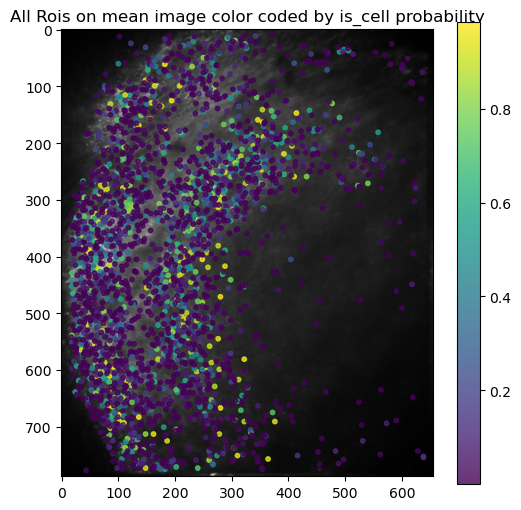

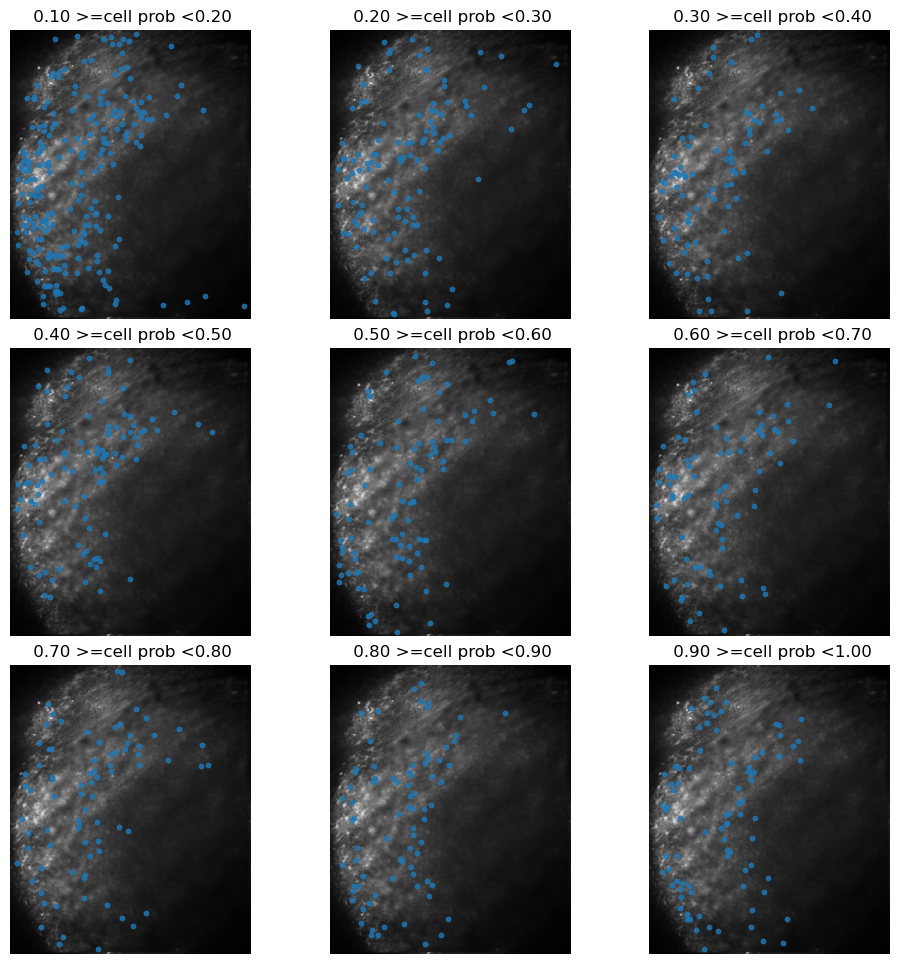

In [11]:
# preprocess s2p roi traces (iscell probability filter, normalization of dye loading using median)

fig, fig2= am.plot_s2proi(stat,iscell,ops)
PDF.savefig(fig) # save in pdf
PDF.savefig(fig2)

In [12]:
iscell_thresh= float( input('Select threshold based on s2p cell probability (0 < x <= 1):'))

while not 0 < iscell_thresh <=1:
    print('Must be an integer or float between 0 and 1, please enter again ')
    iscell_thresh= float( input('Define is cell threshold (ie. 0.5):'))

print(f'Selected iscell threshold is {iscell_thresh}')

prob_cell=iscell.T[1]
selected_index= np.argwhere(prob_cell>iscell_thresh)
print(f'There are {len(selected_index)} rois above the probability threshold')

Select threshold based on s2p cell probability (0 < x <= 1): 0.5


Selected iscell threshold is 0.5
There are 419 rois above the probability threshold


there are 419 cells out of total identified structure 2564
excluding weird fluorescent traces that have nans as median, the remaining good traces are 418


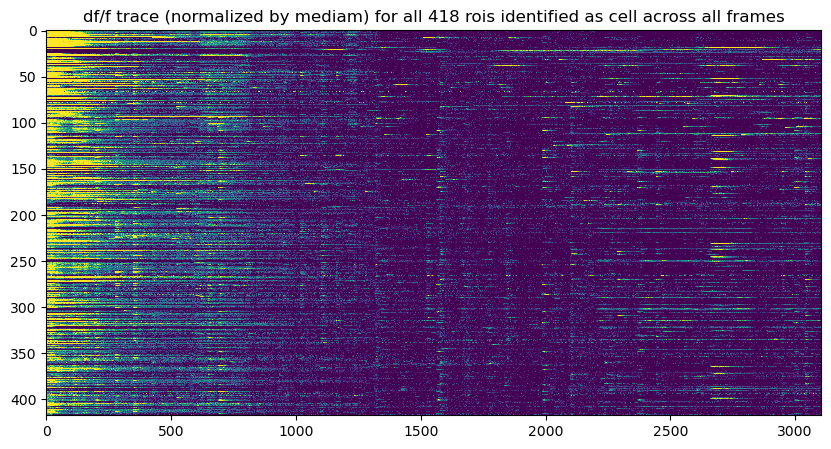

In [13]:
celldff, celldff1= am.norm_fluorescence(F, selected_index)

fig = plt.figure(figsize=(10, 5))
plt.imshow(celldff, vmin=0, vmax=0.3, aspect='auto',interpolation='none')
plt.title (f'df/f trace (normalized by mediam) for all {celldff.shape[0]} rois identified as cell across all frames')

# save in pdf
PDF.savefig(fig)
plt.show()


## roi based analysis

In [15]:
# get constants such as frames of offsets, baseline franmes, evaluation frames

offset= constants.offset
# now defined as -10
baseRange=constants.baseRange
#now defined as the first 5 frame
evRange= constants.evRange
# now defined as frames 10-20

In [16]:
nstim= len(np.unique(stim_pd.stim_id))

# Load stimulus parameters and initialize graphic styles for plotting
if nstim== 48:
     stim_detail, color_dict, style_dict, alpha_dict,marker_dict= util.retinotopy_param(acquisition, stimorder)


Current stimulus type: 4 x 6 ON/OFF stimulus, total numbers of stimulus: 48


cell dff trace array reorganized to (418, 19, 48, 6), with ncells, cycwindow-1, stim_id, max repetition


100%|█████████████████████████████████████████████████████████████████████████████████| 48/48 [00:00<00:00, 727.29it/s]


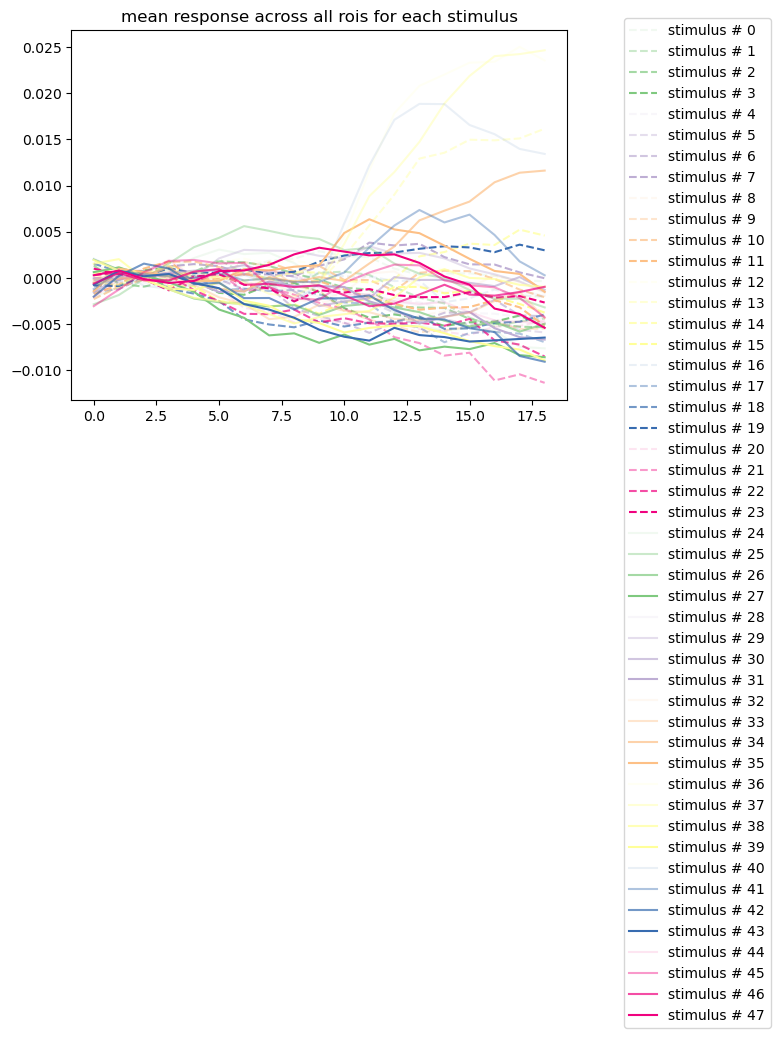

In [17]:
reorganized_trace= am.reorganize_dff(celldff, cycWindow, nstim, nstimrep,stim_pd,offset, baseRange)
# organize traces for each roi in to each cycle for each stimulusid and for each repetition and subtract baseline from them

fig= am.plot_avgtrace(reorganized_trace, color_dict, style_dict,alpha_dict)
# trace for each stimulus- averaged across all repititions and all rois

# save in pdf
PDF.savefig(fig,  bbox_inches='tight')
plt.show()


flights = sns.load_dataset("flights")

may_flights = flights.query("month == 'May'")
test= sns.lineplot(data=may_flights, x="year", y="passengers")

with PdfPages('test.pdf') as pdf_pages:
    pdf_pages.savefig(test.figure)

calculating rois that are positively modulated by each stimuli


100%|██████████████████████████████████████████████████████████████████████████████████| 48/48 [00:04<00:00, 11.16it/s]


calculating rois that are negatively modulated by each stimuli


100%|██████████████████████████████████████████████████████████████████████████████████| 48/48 [00:04<00:00, 11.14it/s]


prepare array for clustering based on significant response  - (418, 48), which is n structure * (nstimulus), for increase(1) and decrease(-1) in fluorescent upon stimulus


<Figure size 640x480 with 0 Axes>

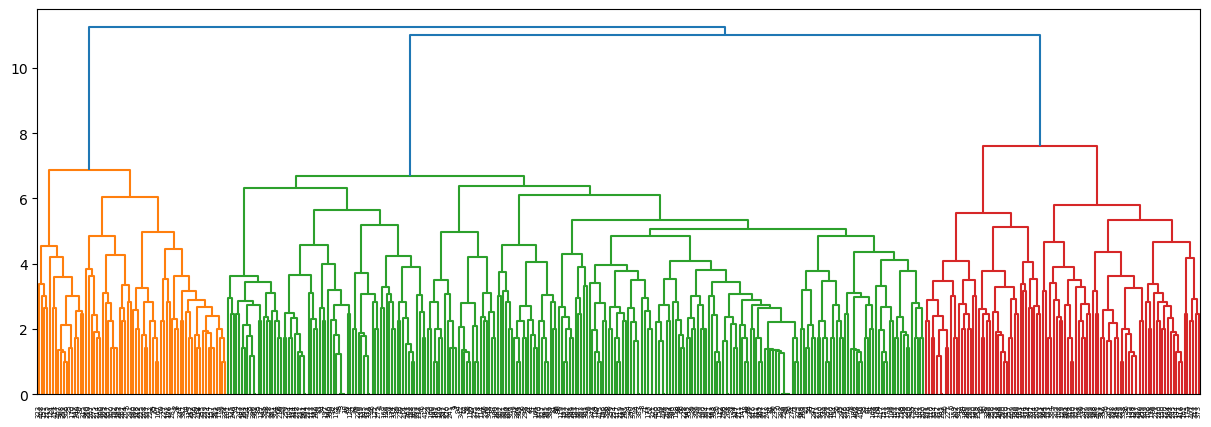

D:\Anaconda\envs\2p-analysis\lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


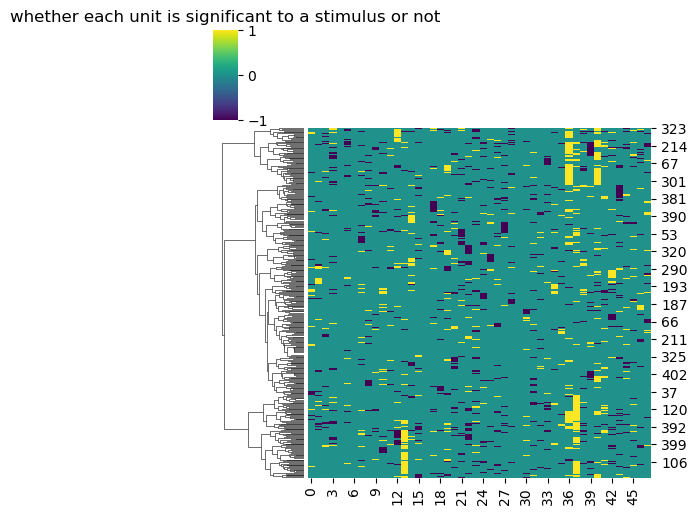

In [19]:
# arrange data for wilcoxon rank sum test, then
# find neurons that have greater responses during the evoked window than baseline

print('calculating rois that are positively modulated by each stimuli')
responsive_inc=am.find_responsive(reorganized_trace, baseRange, evRange, nstim, tail='greater')

print('calculating rois that are negatively modulated by each stimuli')
responsive_dec=am.find_responsive(reorganized_trace, baseRange, evRange, nstim, tail='less')

# clustering based on statistically significant or not
# keep responsive increase and responsive decrease orthogonal during clustering
# ie. input array is nroi x (1 nstimulus) but increase is +1, decrease is -1, not significant =0

cluster_input_responsive=responsive_inc+(responsive_dec*-1)
print(f'prepare array for clustering based on significant response  - {cluster_input_responsive.shape}, which is n structure * (nstimulus), for increase(1) and decrease(-1) in fluorescent upon stimulus')

Z, fig= am.response_cluster(cluster_input_responsive)
# hierarchical clustering

# save in pdf
PDF.savefig(fig, bbox_inches='tight')

In [20]:
# ask user input to cut dendrogram, ask again if not happy with cluster number

while True: 
    big_cluster,t = am.define_cluster(Z)
    cluster_confirm= input('Press enter to continue, press anything else to to redefine cutoff:')
    if cluster_confirm =="":
        break
    else:
        print("retry")


Input cut off level based on dendrogram (int or decimal >0):  7


number of arbitrary cluster= 4


Press enter to continue, press anything else to to redefine cutoff: 


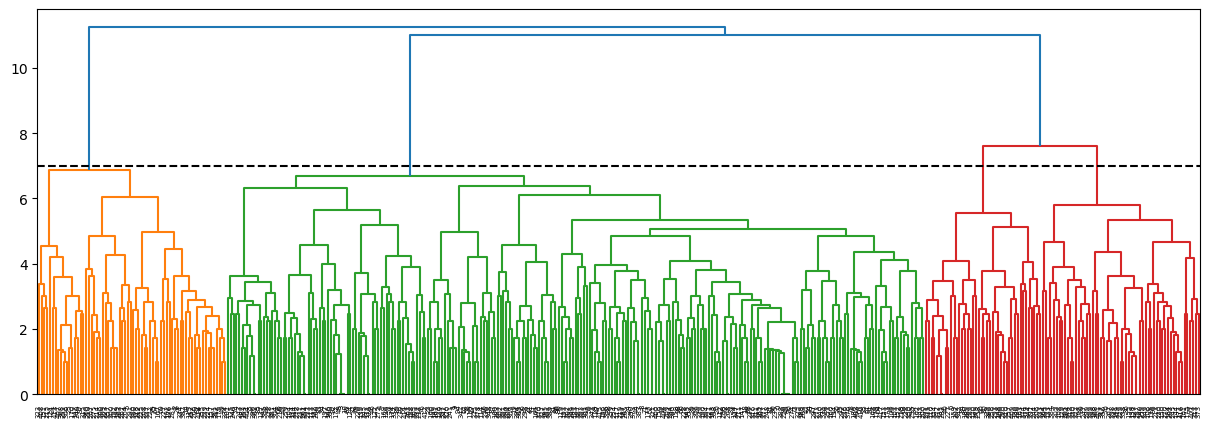

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster 

fig, ax=plt.subplots(figsize=(15, 5))
dn = dendrogram(Z)
ax.axhline(t,ls= '--', c='k')
# plot a horizontal cut off line to the dendrogram

# save in pdf
PDF.savefig(fig)

plt.show()

Plotting positions of rois in each cluster


100%|████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00,  4.60it/s]


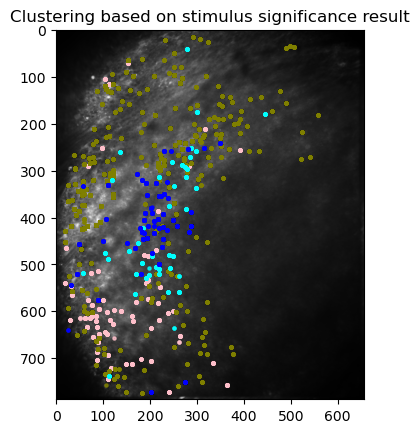

In [22]:
cellstat=stat[selected_index.flatten()]
# stat from structures pre-selected (ie. by a defined threshold of iscell probability)

cellstat=cellstat[~np.isnan(celldff1.min(axis=1))]
# also remove those indices that were dividing by zero during our celldff process

fig= am.plot_clust_roi(big_cluster, cellstat,ops)
# plot out the roi location

# save in pdf
PDF.savefig(fig)

In [23]:
# prepare data for the next plots

mean_cluster_response= np.mean(cluster_input_responsive, axis=0)
mean_cluster_response.shape[0]

rng_seed = np.random.default_rng() # initialize rng generator

xval=np.arange(0, mean_cluster_response.shape[0]) # create x variables for scatter plot
temp= np.arange(0,mean_cluster_response.shape[0]/2) #convert x value to stimulus index (ie, stimulus 34 is actually still stimulus 17 but those show decrease response toward this stimulus)
#x_labels= np.repeat(temp[np.newaxis,:], 2, axis=0).flatten() 

# calculate trace for each stimulus- averaged across all repititions
avg_stim_trace= np.nanmean(reorganized_trace, axis= 3)

D:\Anaconda\envs\2p-analysis\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Anaconda\envs\2p-analysis\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Anaconda\envs\2p-analysis\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Anaconda\envs\2p-analysis\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

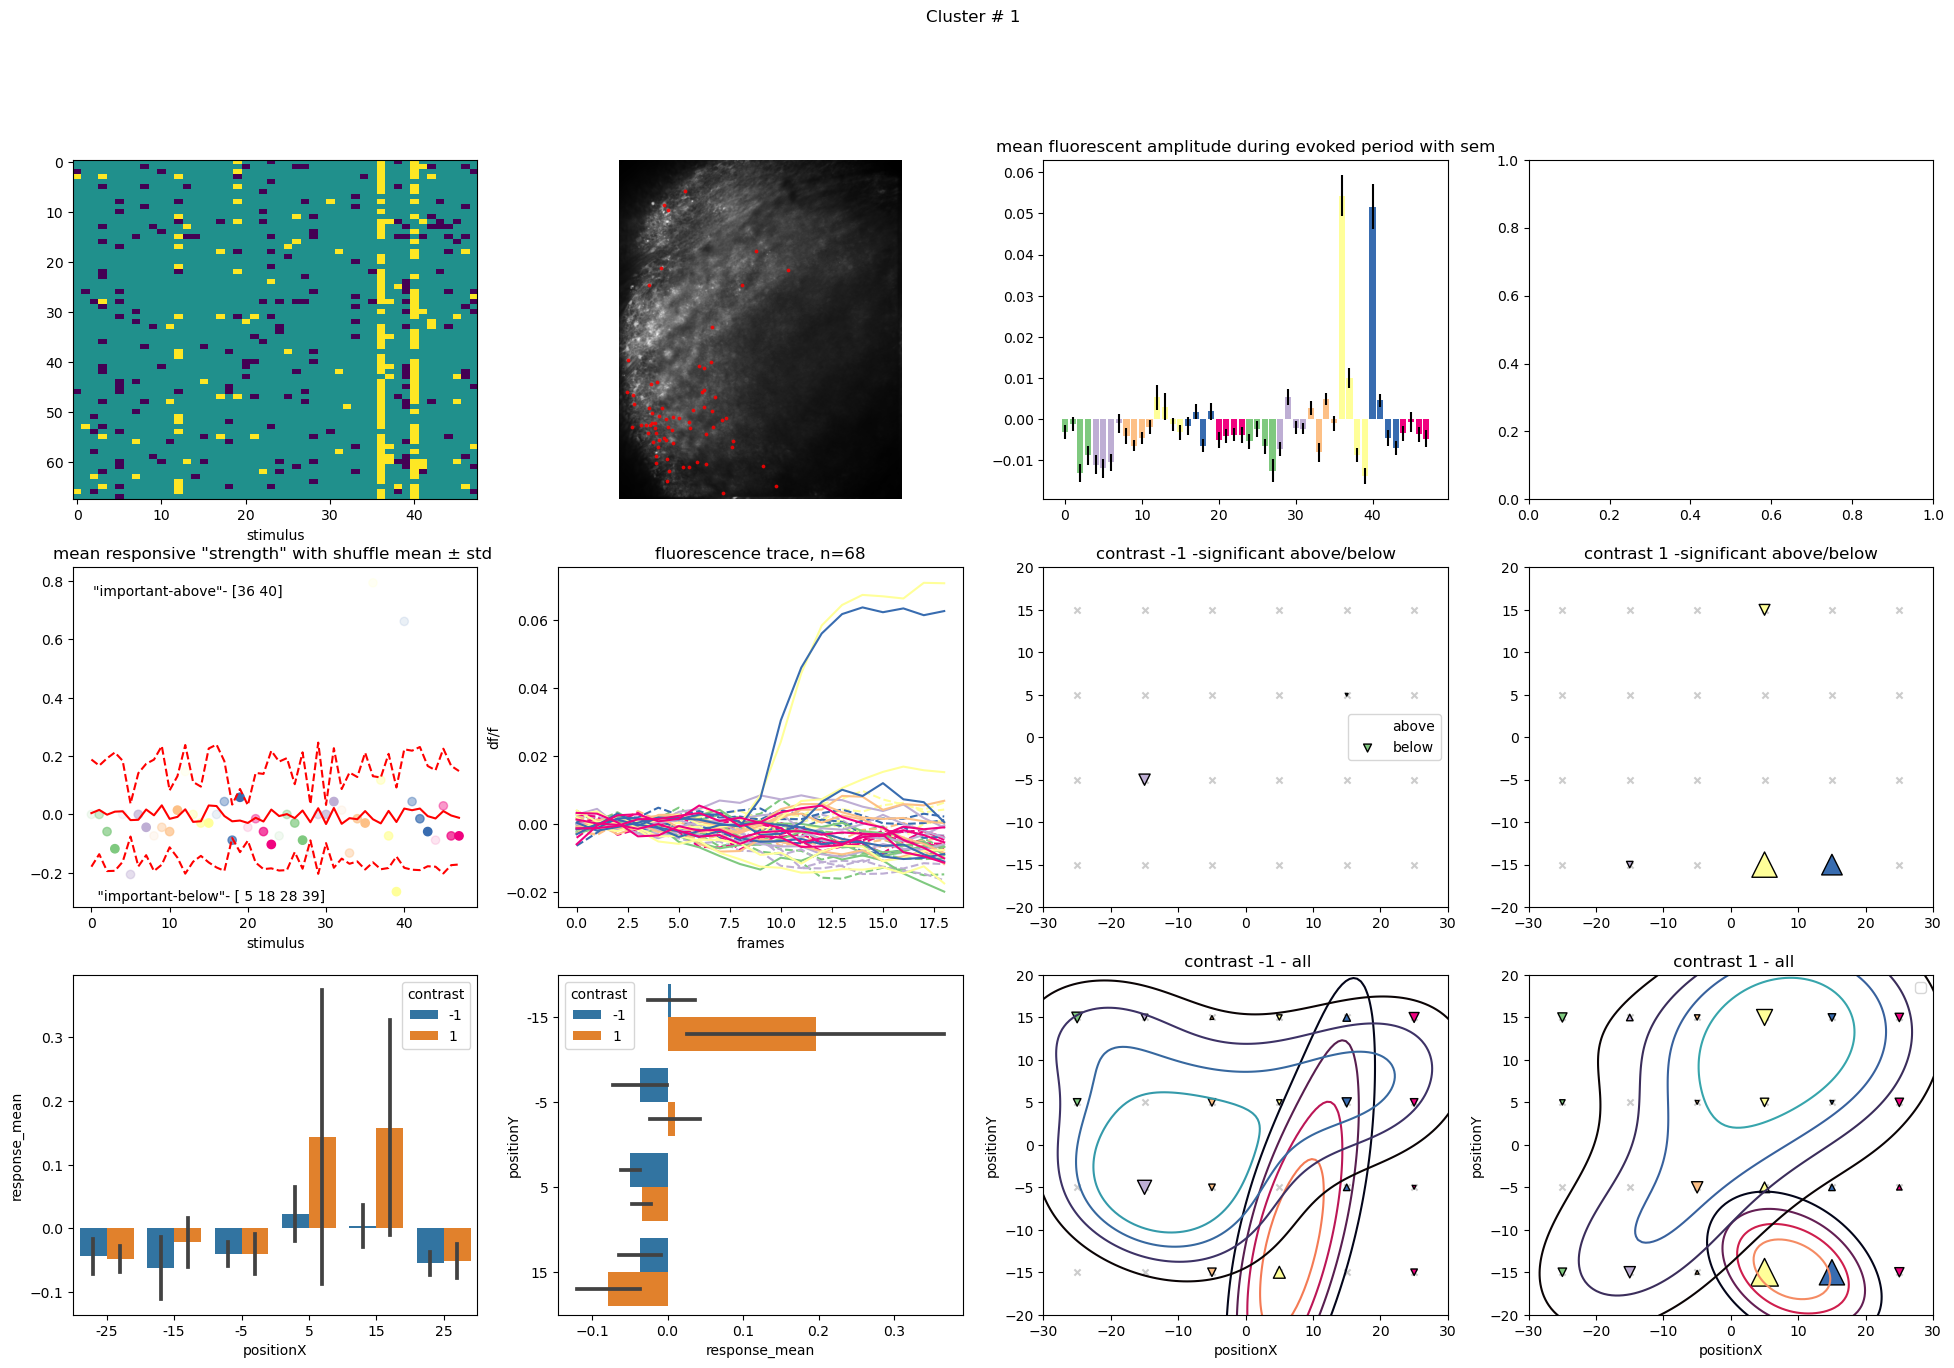

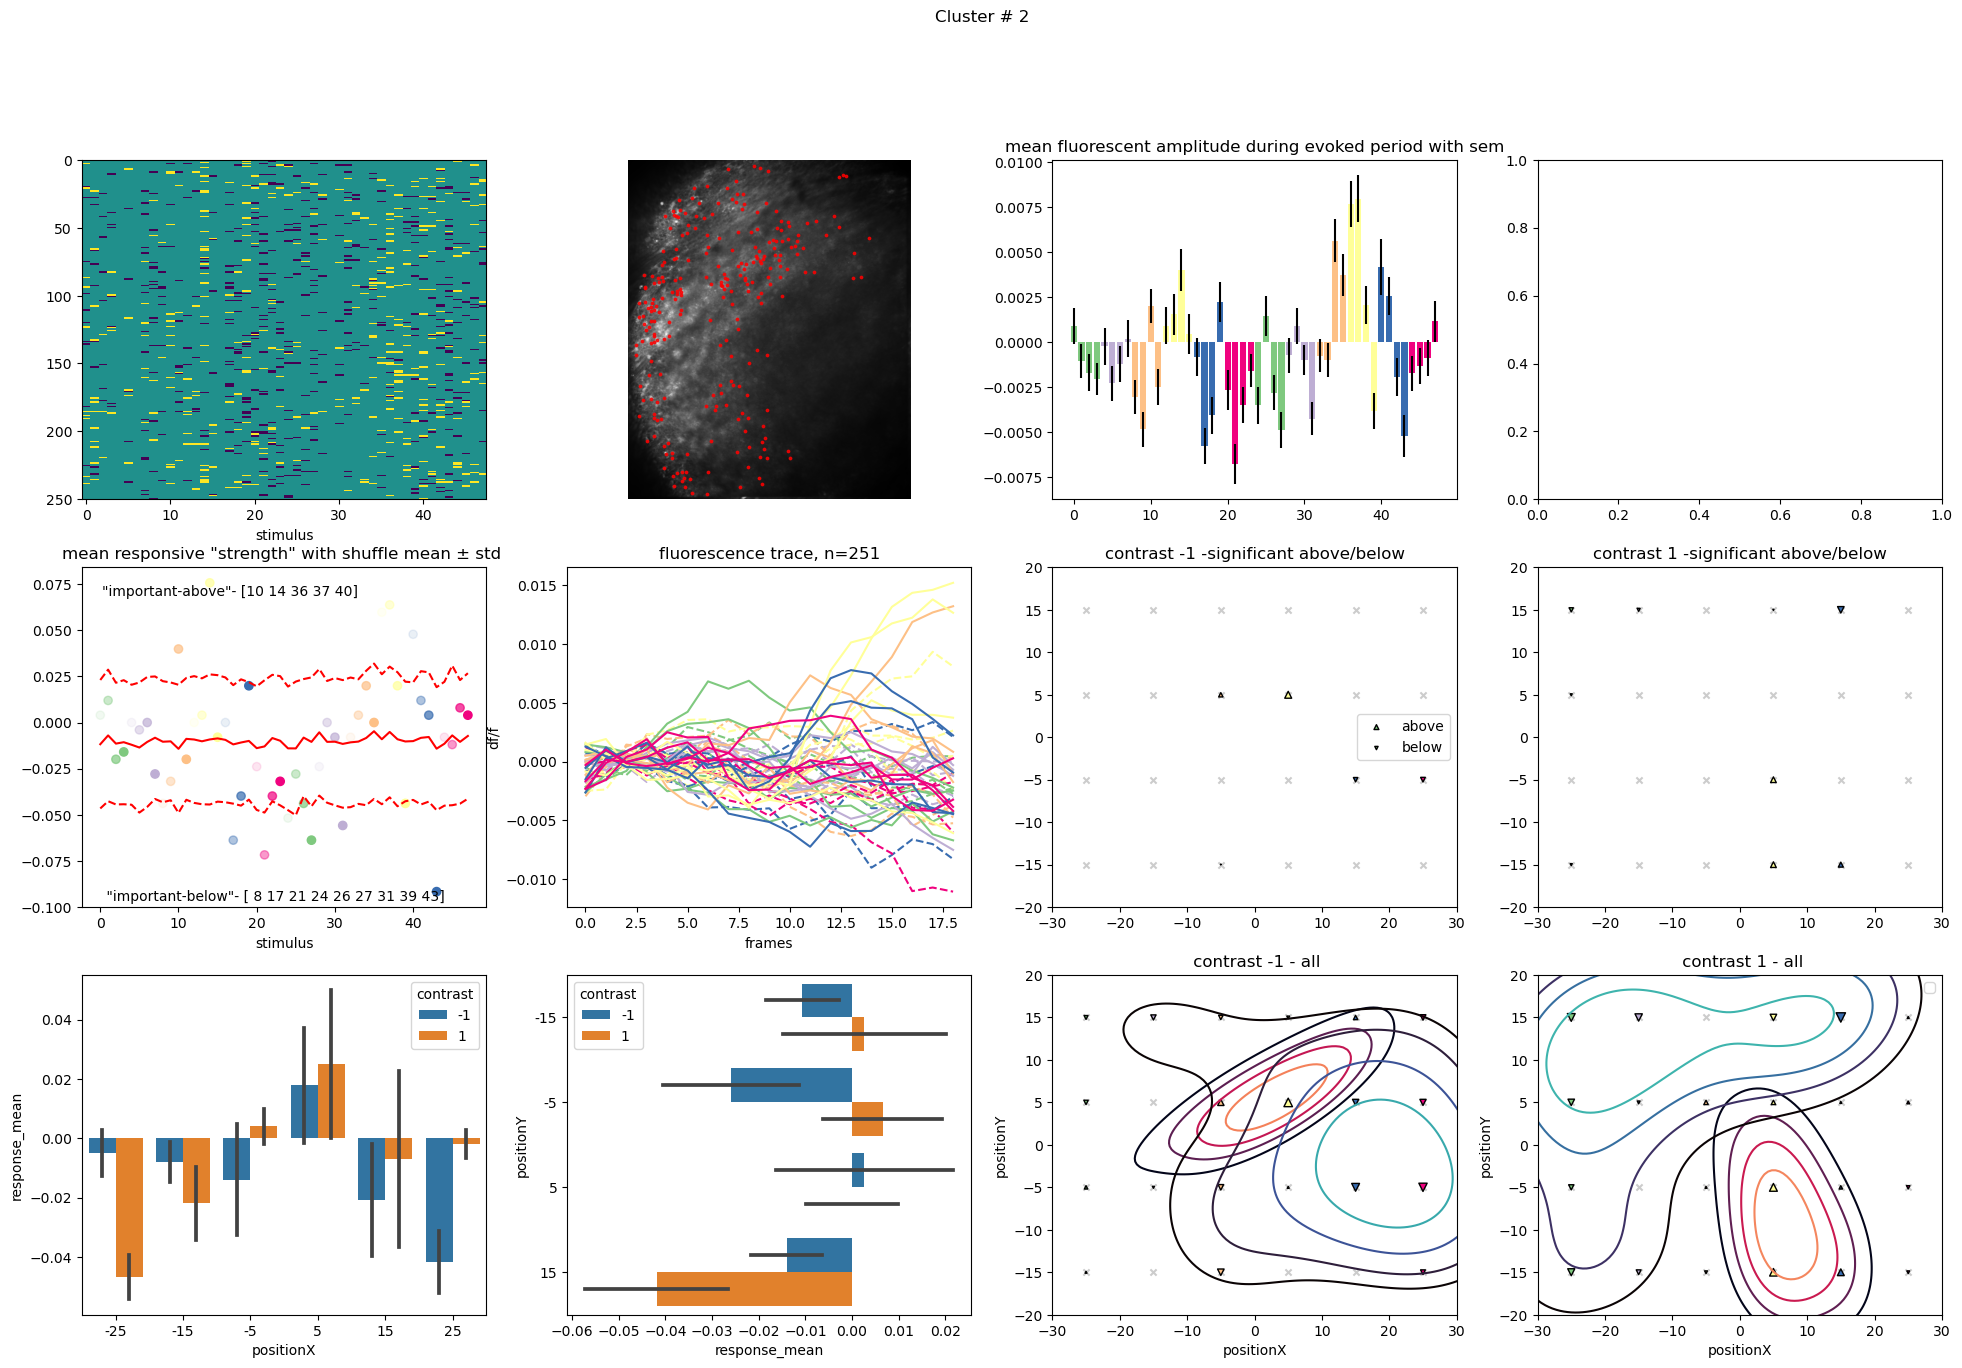

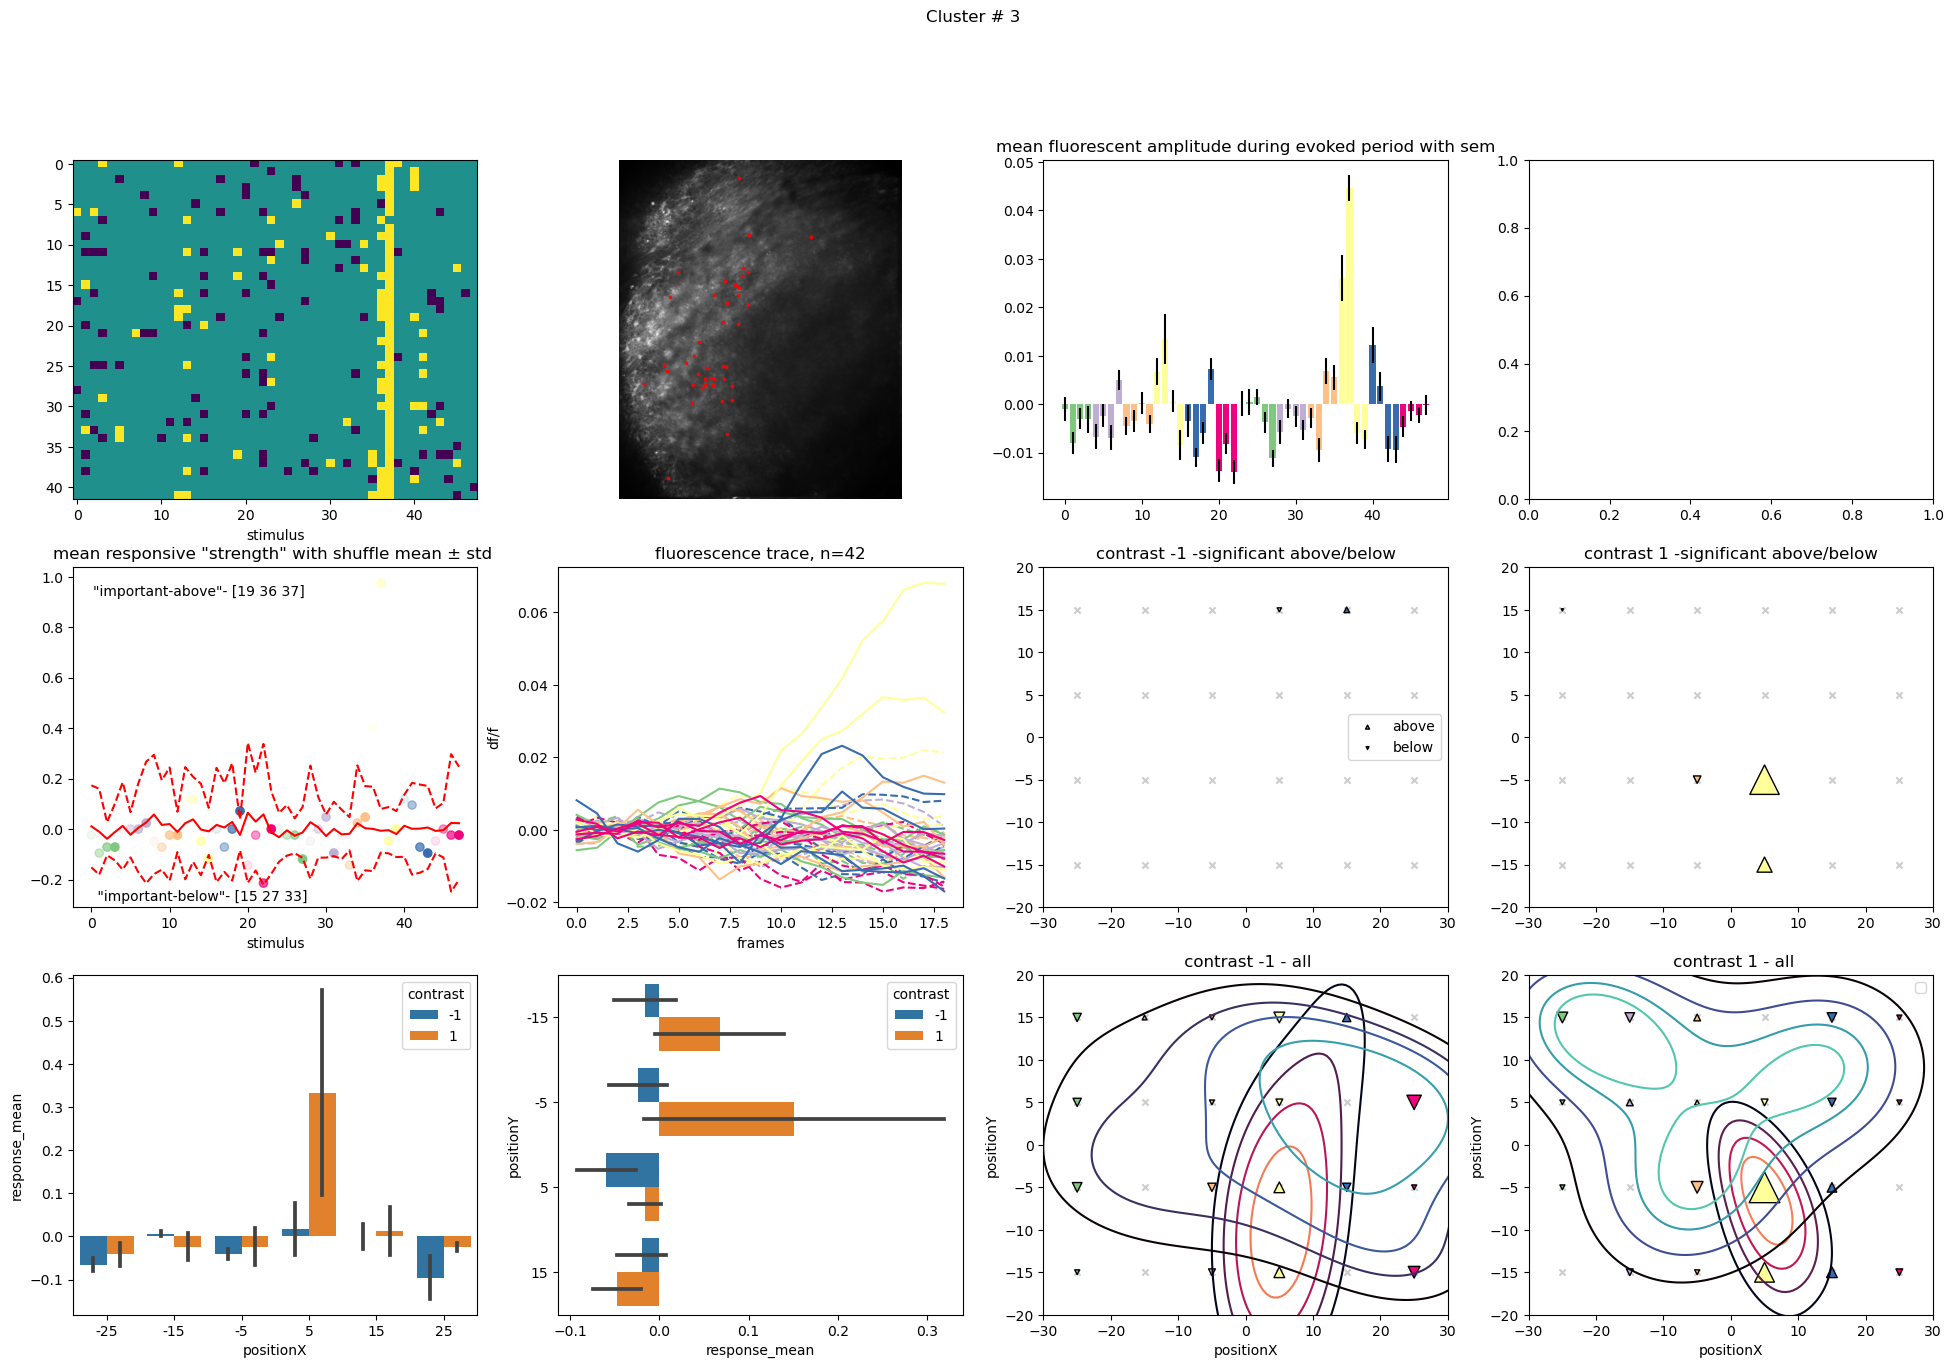

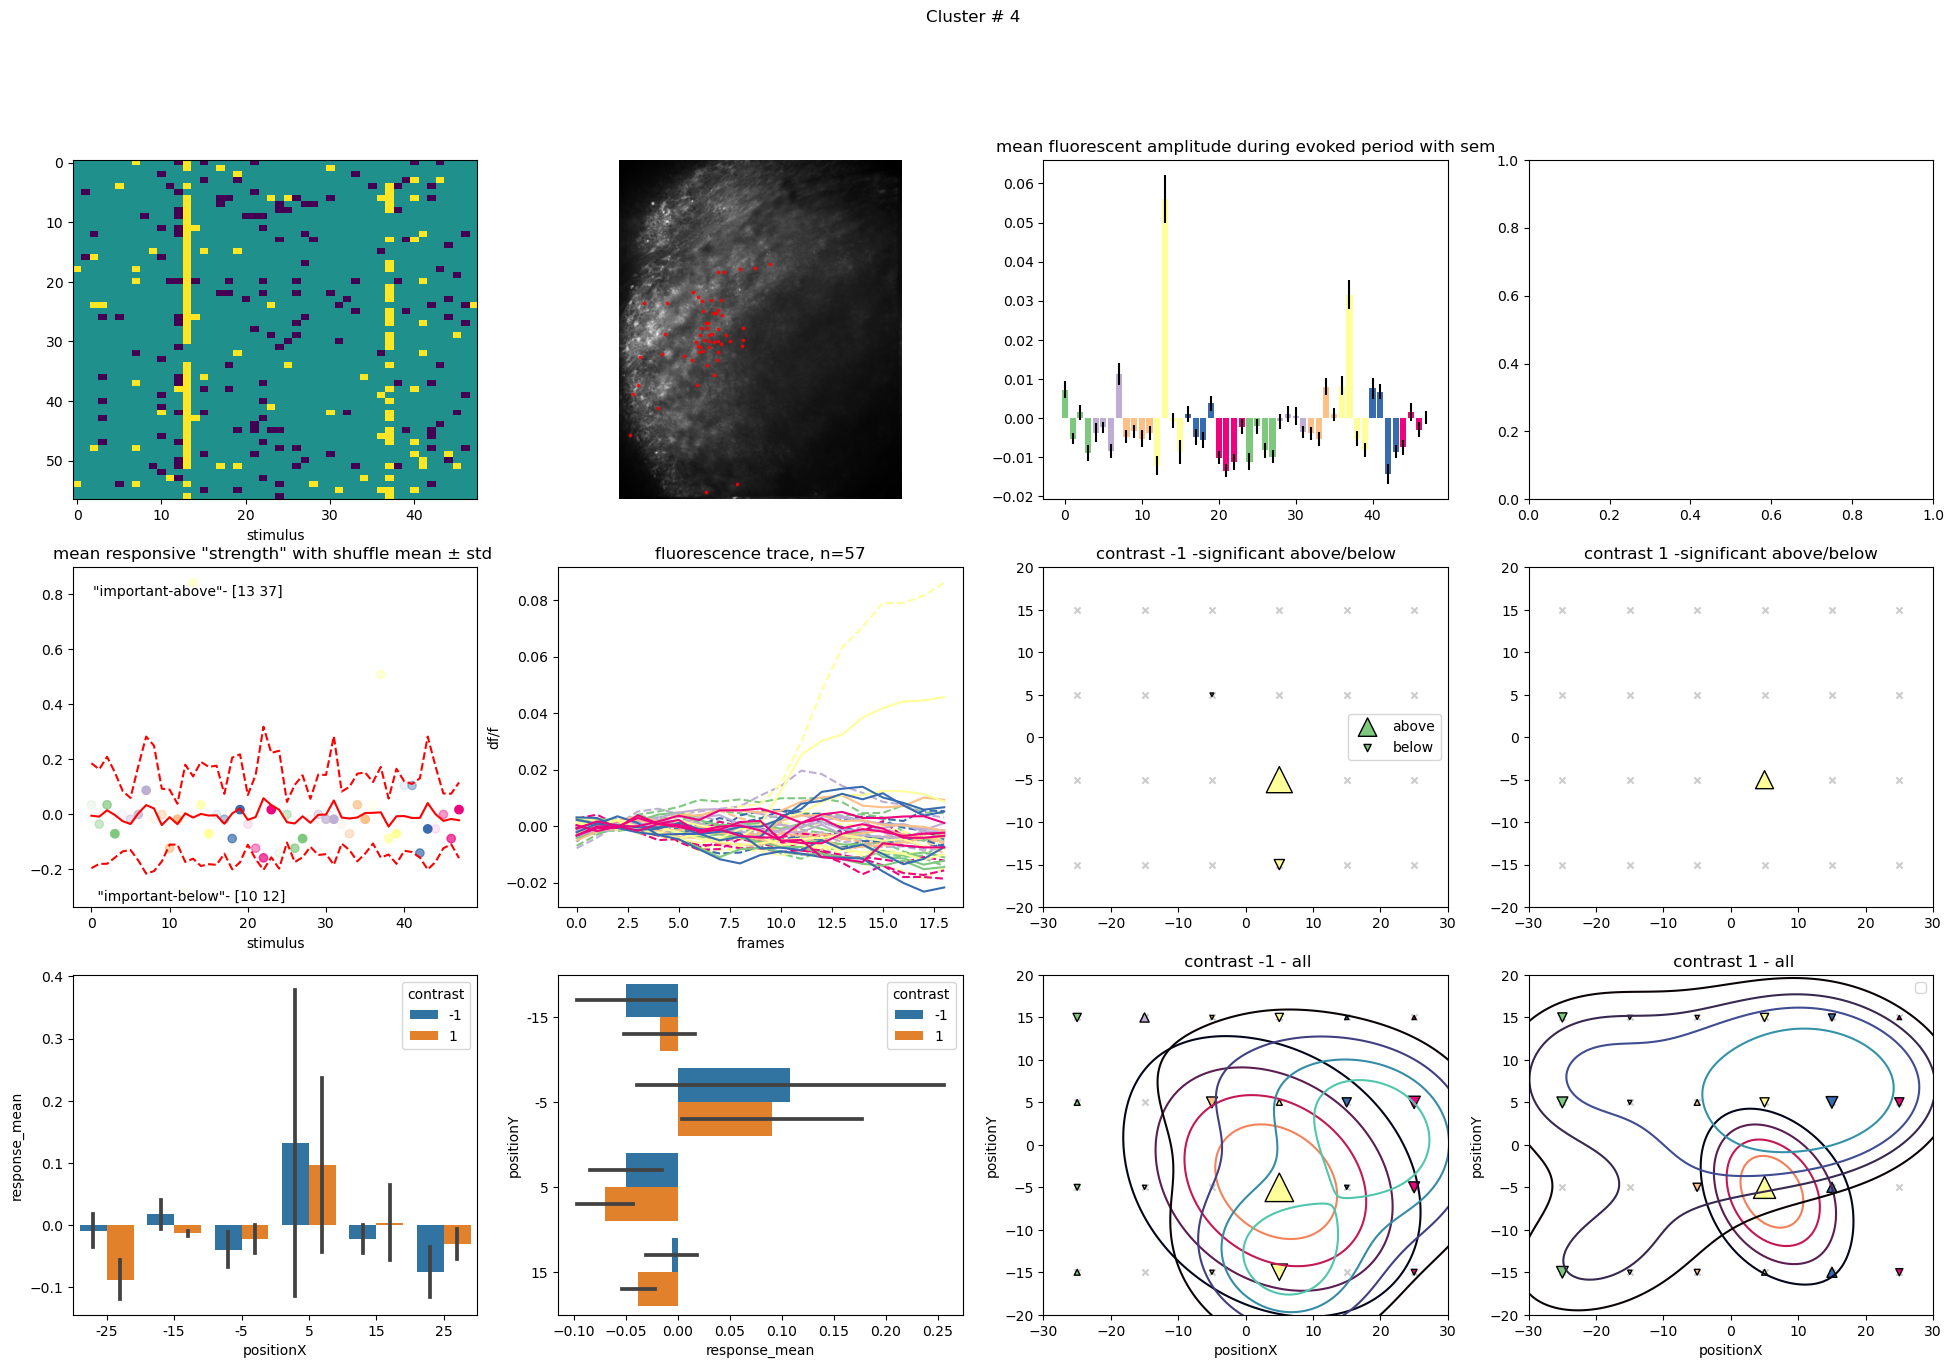

In [24]:
import seaborn as sns

if nstim==48:
    # plotting cluster properties for 6x4
    for i in range(1,big_cluster.max()+1):
    
        # prepare data for plotting
        cluster_cells= cellstat[big_cluster==i]
        cluster_response= cluster_input_responsive[big_cluster==i]
        cluster_celldfs= avg_stim_trace[big_cluster==i,:,:]
        n_permute=cluster_response.shape[0]  # permute nroi times (ie. if the cluster have 10 rois, then permute 10 times)..?
        
        chance_mean,chance_std= util.permute_cluster_response(cluster_response, n_permute, rng_seed)
        
        this_clusterpd= util.arrange_cluster_df(cluster_response, chance_mean,chance_std, stim_detail) 
        # prepare dataframe with stim info, mean and std of responses, calculate which responses are more important by comparing it with chance mean + or - chance std
    
        important_stimulus=[]
        important_stimulus.append(np.argwhere(this_clusterpd['care_sig_inc_weight']>0).flatten())# a stimulus is important if its 1 std (shuffled data) away from the mean of shuffled data
        important_stimulus.append(np.argwhere(this_clusterpd['care_sig_dec_weight']<0).flatten())
        
        fig, axs = plt.subplots(3,4, figsize=(24,15), height_ratios=[1,1,1], width_ratios=[3,3,3,3])
        # create subplots
    
        center_row= []
        center_col = []
        
        for j in cluster_cells:
            center_row.append( j['med'][0])
            center_col.append( j['med'][1])
        
        axs[0,0].imshow(cluster_response, aspect='auto', vmin=-1, vmax=1, interpolation='None')
        axs[0,0].set_xlabel('stimulus')
    
        
        axs[0,1].imshow(ops['meanImg'], cmap='gray')
        axs[0,1].scatter(center_col, center_row, s= 3, alpha= 0.8, color='r')
        axs[0,1].axis('off')
    
        util.plot_amp_ev(cluster_celldfs, evRange, xval, color_dict, axs=axs[0,2])
        axs[0,2].set_title('mean fluorescent amplitude during evoked period with sem')
        #sns.barplot(data=this_clusterpd, x='positionX',y='care_sig_dec_weight',hue= 'contrast', errorbar='se', ax= axs[0,3])
        #axs[0,2].set_ylim([0, 0.2])
        #axs[0,3].set_ylim([-0.2, 0])
    
        
        axs[1,0].scatter(xval, this_clusterpd['response_mean'], c=color_dict, alpha=alpha_dict)
        #axs[1,0].set_xticks(xval)
        axs[1,0].set_xlabel('stimulus')
        #axs[1,0].errorbar(xval, mean_cluster_response, yerr=std_cluster_response, marker='') # need to figure out how to make the error bar also hsv color
    
        axs[1,0].plot(chance_mean, color='r', linestyle='-') # plot mean and 2 std of data permuted x time- serve as a chance level control..?
        axs[1,0].plot(chance_mean + chance_std, color='r', linestyle='--')
        axs[1,0].plot(chance_mean - chance_std, color='r', linestyle='--')
        axs[1,0].set_title('mean responsive "strength" with shuffle mean ± std ')
        axs[1,0].text(0.05, 0.95, f'"important-above"- {important_stimulus[0]}', horizontalalignment='left', verticalalignment='top', transform=axs[1,0].transAxes)
        axs[1,0].text(0.05, 0.05, f' "important-below"- {important_stimulus[1]}', horizontalalignment='left', verticalalignment='top', transform=axs[1,0].transAxes)
    
    
        for k in range(0,cluster_celldfs.shape[2]):
            axs[1,1].plot(np.mean(cluster_celldfs[:,:, k], axis=0), label=f'stimulus # {k}',color= color_dict[k], linestyle= style_dict[k])
            axs[1,1].set_title(f'fluorescence trace, n={cluster_celldfs.shape[0]}')
        #axs[1,1].legend(loc='best', fontsize='x-small')
        axs[1,1].set_ylabel('df/f')
        axs[1,1].set_xlabel('frames')
        
    
        on_pd=this_clusterpd[this_clusterpd['contrast']==1]
        off_pd=this_clusterpd[this_clusterpd['contrast']==-1]
        
        util.plot_scatter_sig(off_pd, color_dict, axs=axs[1,2])
        axs[1,2].legend()
        axs[1,2].set_title('contrast -1 -significant above/below')
        axs[1,2].set_xlim([-30, 30])
        axs[1,2].set_ylim([-20, 20])
        
        util.plot_scatter_sig(on_pd, color_dict, axs=axs[1,3])
        axs[1,3].set_title('contrast 1 -significant above/below')
        axs[1,3].set_xlim([-30, 30])
        axs[1,3].set_ylim([-20, 20])
        
    
        util.plot_scatter_kde_all(off_pd, color_dict, axs=axs[2,2])
        axs[2,2].set_title(' contrast -1 - all')
        axs[2,2].set_xlim([-30, 30])
        axs[2,2].set_ylim([-20, 20])
        
        
        util.plot_scatter_kde_all(on_pd, color_dict, axs=axs[2,3])
        axs[2,3].legend()
        axs[2,3].set_title(' contrast 1 - all')
        axs[2,3].set_xlim([-30, 30])
        axs[2,3].set_ylim([-20, 20])
        
    
        sns.barplot(data=this_clusterpd, x='positionX',y='response_mean', hue='contrast', errorbar='se', ax=axs[2,0])
        sns.barplot(data=this_clusterpd, y='positionY',x='response_mean', hue='contrast', errorbar='se', orient='h', ax=axs[2,1])
    
        #fig.tight_layout()
        fig.suptitle(f'Cluster # {i}')
    
    
        # save in pdf INSIDE for loop so each for loop is one page!!!
        PDF.savefig(fig)

In [25]:
# close the PDF
PDF.close()
